In [ ]:
# ============================================================
# 1. Pre-requisites
# ============================================================
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [ ]:
# ============================================================
# 2. Load Raw Data
# ============================================================
# Generation data
p1_gen = pd.read_csv('/content/Plant_1_Generation_Data.csv')
p2_gen = pd.read_csv('/content/Plant_2_Generation_Data.csv')

# Weather data
p1_weather = pd.read_csv('/content/Plant_1_Weather_Sensor_Data.csv')
p2_weather = pd.read_csv('/content/Plant_2_Weather_Sensor_Data.csv')

print("Plant 1 Generation:", p1_gen.shape)
print("Plant 2 Generation:", p2_gen.shape)
print("Plant 1 Weather:", p1_weather.shape)
print("Plant 2 Weather:", p2_weather.shape)

Plant 1 Generation: (68778, 7)
Plant 2 Generation: (67698, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Weather: (3259, 6)


In [ ]:
# ============================================================
# 3. Fix Datetime & Aggregate to Plant Level
# ============================================================
# Fix inconsistent datetime format in Plant 1 generation
p1_gen['DATE_TIME'] = pd.to_datetime(p1_gen['DATE_TIME'],
                                      dayfirst=True)
p2_gen['DATE_TIME'] = pd.to_datetime(p2_gen['DATE_TIME'])
p1_weather['DATE_TIME'] = pd.to_datetime(p1_weather['DATE_TIME'])
p2_weather['DATE_TIME'] = pd.to_datetime(p2_weather['DATE_TIME'])

# Aggregate inverter-level generation to plant-level per timestamp
# We sum DC and AC power (total plant output), average yield metrics
p1_gen_agg = p1_gen.groupby('DATE_TIME').agg(
    DC_POWER=('DC_POWER', 'sum'),
    AC_POWER=('AC_POWER', 'sum'),
    DAILY_YIELD=('DAILY_YIELD', 'mean'),
    TOTAL_YIELD=('TOTAL_YIELD', 'mean')
).reset_index()

p2_gen_agg = p2_gen.groupby('DATE_TIME').agg(
    DC_POWER=('DC_POWER', 'sum'),
    AC_POWER=('AC_POWER', 'sum'),
    DAILY_YIELD=('DAILY_YIELD', 'mean'),
    TOTAL_YIELD=('TOTAL_YIELD', 'mean')
).reset_index()

print("Plant 1 aggregated shape:", p1_gen_agg.shape)
print("Plant 2 aggregated shape:", p2_gen_agg.shape)
print("\nSample Plant 1 aggregated:")
print(p1_gen_agg.head(3))

Plant 1 aggregated shape: (3158, 5)
Plant 2 aggregated shape: (3259, 5)

Sample Plant 1 aggregated:
            DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD   TOTAL_YIELD
0 2020-05-15 00:00:00       0.0       0.0          0.0  6.837223e+06
1 2020-05-15 00:15:00       0.0       0.0          0.0  6.837223e+06
2 2020-05-15 00:30:00       0.0       0.0          0.0  6.837223e+06


In [ ]:
# ============================================================
# 4. Merge Generation with Weather Data
# ============================================================
p1 = pd.merge(p1_gen_agg, p1_weather[['DATE_TIME',
              'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
              'IRRADIATION']], on='DATE_TIME', how='inner')

p2 = pd.merge(p2_gen_agg, p2_weather[['DATE_TIME',
              'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
              'IRRADIATION']], on='DATE_TIME', how='inner')

print("Plant 1 merged shape:", p1.shape)
print("Plant 2 merged shape:", p2.shape)
print("\nMissing values Plant 1:", p1.isnull().sum().sum())
print("Missing values Plant 2:", p2.isnull().sum().sum())

Plant 1 merged shape: (3157, 8)
Plant 2 merged shape: (3259, 8)

Missing values Plant 1: 0
Missing values Plant 2: 0


In [ ]:
# ============================================================
# 5. Feature Engineering
# ============================================================
def engineer_features(df, plant_name):
    df = df.copy()

    # Time-based features
    df['HOUR'] = df['DATE_TIME'].dt.hour
    df['MINUTE'] = df['DATE_TIME'].dt.minute
    # Convert hour to continuous time (e.g. 14:30 = 14.5)
    df['TIME_OF_DAY'] = df['HOUR'] + df['MINUTE'] / 60
    df['DAY_OF_WEEK'] = df['DATE_TIME'].dt.dayofweek
    df['DAY_OF_MONTH'] = df['DATE_TIME'].dt.day
    df['MONTH'] = df['DATE_TIME'].dt.month

    # Add plant label
    df['PLANT'] = plant_name

    print(f"{plant_name} — Final shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    return df

p1 = engineer_features(p1, 'Plant_1')
p2 = engineer_features(p2, 'Plant_2')

print("\nSample final data:")
print(p1.head(3))

Plant_1 — Final shape: (3157, 15)
Columns: ['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'MINUTE', 'TIME_OF_DAY', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH', 'PLANT']
Plant_2 — Final shape: (3259, 15)
Columns: ['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'MINUTE', 'TIME_OF_DAY', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH', 'PLANT']

Sample final data:
            DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD   TOTAL_YIELD  \
0 2020-05-15 00:00:00       0.0       0.0          0.0  6.837223e+06   
1 2020-05-15 00:15:00       0.0       0.0          0.0  6.837223e+06   
2 2020-05-15 00:30:00       0.0       0.0          0.0  6.837223e+06   

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  HOUR  MINUTE  \
0            25.184316           22.857507          0.0     0       0   
1            25.084589           22.761

In [ ]:
# ============================================================
# 6. Basic Statistics Summary
# ============================================================
print("=" * 50)
print("PLANT 1 — Descriptive Statistics")
print("=" * 50)
print(p1[['AC_POWER', 'DC_POWER', 'IRRADIATION',
          'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']].describe().round(2))

print("\n" + "=" * 50)
print("PLANT 2 — Descriptive Statistics")
print("=" * 50)
print(p2[['AC_POWER', 'DC_POWER', 'IRRADIATION',
          'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']].describe().round(2))

PLANT 1 — Descriptive Statistics
       AC_POWER   DC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  \
count   3157.00    3157.00      3157.00              3157.00   
mean    6704.83   68560.02         0.23                25.56   
std     8604.22   88055.84         0.30                 3.35   
min        0.00       0.00         0.00                20.40   
25%        0.00       0.00         0.00                22.74   
50%      814.88    8430.20         0.03                24.68   
75%    13752.11  140409.89         0.45                27.94   
max    29150.21  298937.79         1.22                35.25   

       MODULE_TEMPERATURE  
count             3157.00  
mean                31.18  
std                 12.27  
min                 18.14  
25%                 21.13  
50%                 24.80  
75%                 41.45  
max                 65.55  

PLANT 2 — Descriptive Statistics
       AC_POWER  DC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  \
count   3259.00   3259.00      3259.00   

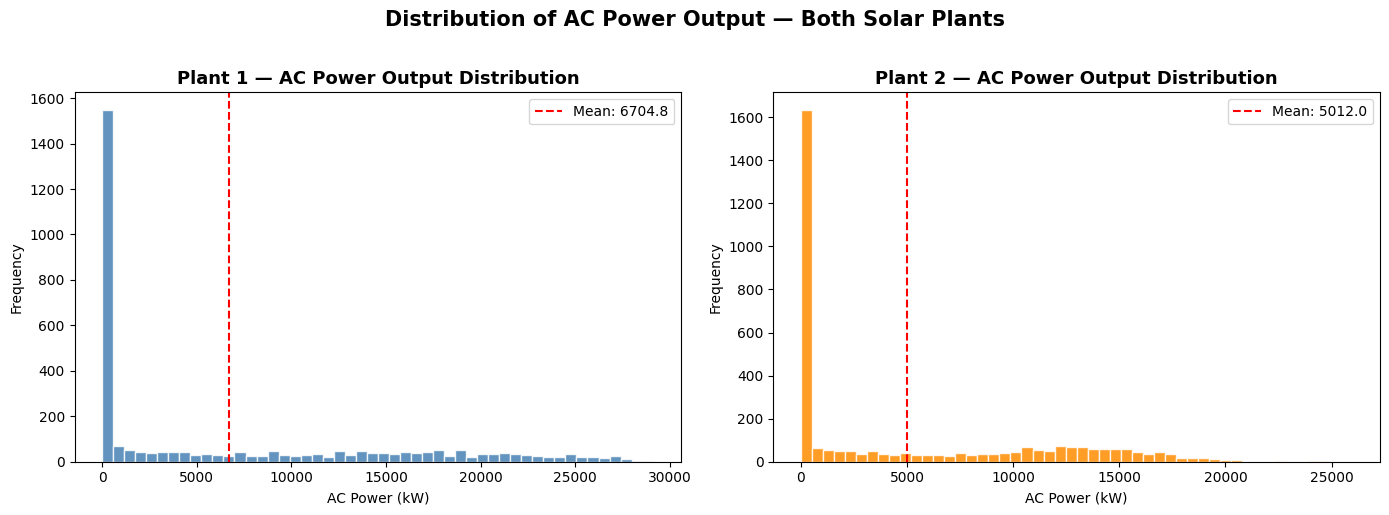

Figure 1 saved.


In [ ]:
# ============================================================
# 7. AC Power Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plant 1
axes[0].hist(p1['AC_POWER'], bins=50, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Plant 1 — AC Power Output Distribution',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('AC Power (kW)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(p1['AC_POWER'].mean(), color='red',
                linestyle='--', label=f"Mean: {p1['AC_POWER'].mean():.1f}")
axes[0].legend()

# Plant 2
axes[1].hist(p2['AC_POWER'], bins=50, color='darkorange',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Plant 2 — AC Power Output Distribution',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('AC Power (kW)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(p2['AC_POWER'].mean(), color='red',
                linestyle='--', label=f"Mean: {p2['AC_POWER'].mean():.1f}")
axes[1].legend()

plt.suptitle('Distribution of AC Power Output — Both Solar Plants',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_ac_power_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

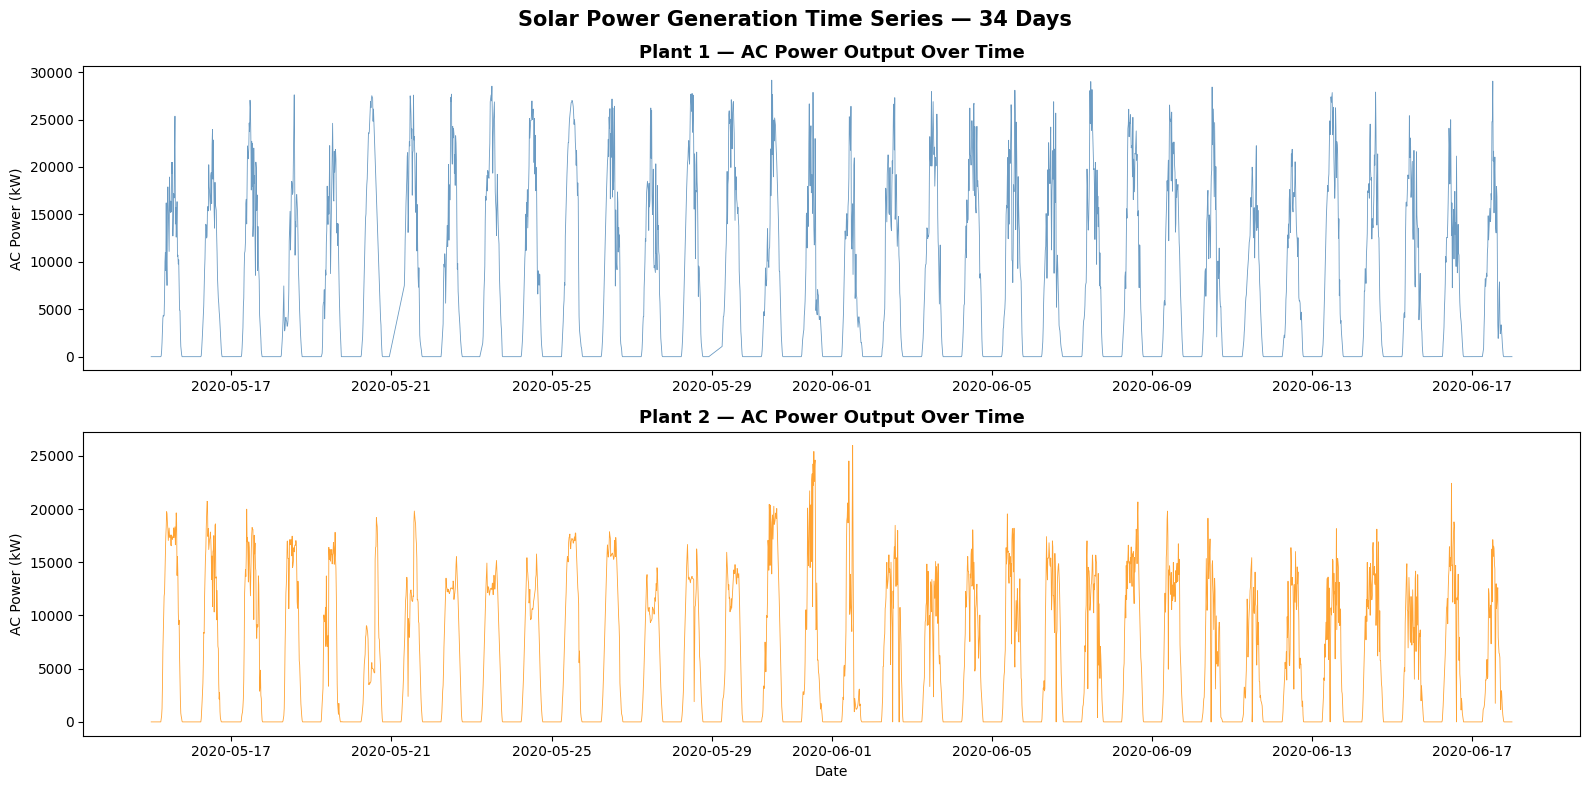

Figure 2 saved.


In [ ]:
# ============================================================
# 8. AC Power Over Time
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(p1['DATE_TIME'], p1['AC_POWER'],
             color='steelblue', linewidth=0.6, alpha=0.8)
axes[0].set_title('Plant 1 — AC Power Output Over Time',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('AC Power (kW)')
axes[0].set_xlabel('')

axes[1].plot(p2['DATE_TIME'], p2['AC_POWER'],
             color='darkorange', linewidth=0.6, alpha=0.8)
axes[1].set_title('Plant 2 — AC Power Output Over Time',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('AC Power (kW)')
axes[1].set_xlabel('Date')

plt.suptitle('Solar Power Generation Time Series — 34 Days',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

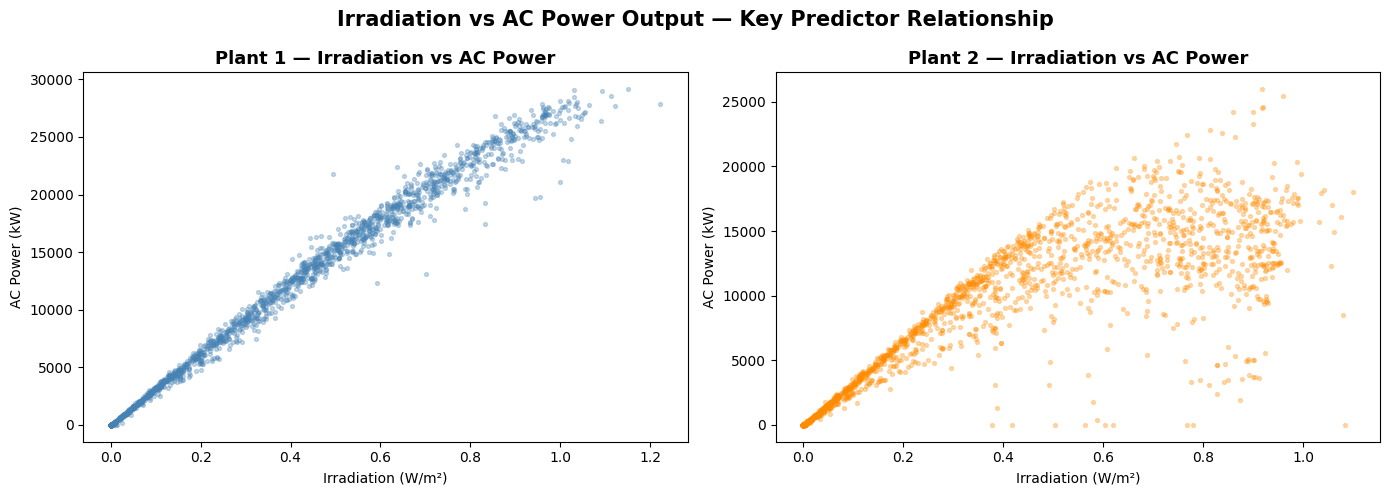

Figure 3 saved.


In [ ]:
# ============================================================
# 9. Irradiation vs AC Power
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(p1['IRRADIATION'], p1['AC_POWER'],
                alpha=0.3, color='steelblue', s=8)
axes[0].set_title('Plant 1 — Irradiation vs AC Power',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Irradiation (W/m²)')
axes[0].set_ylabel('AC Power (kW)')

axes[1].scatter(p2['IRRADIATION'], p2['AC_POWER'],
                alpha=0.3, color='darkorange', s=8)
axes[1].set_title('Plant 2 — Irradiation vs AC Power',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Irradiation (W/m²)')
axes[1].set_ylabel('AC Power (kW)')

plt.suptitle('Irradiation vs AC Power Output — Key Predictor Relationship',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_irradiation_vs_acpower.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

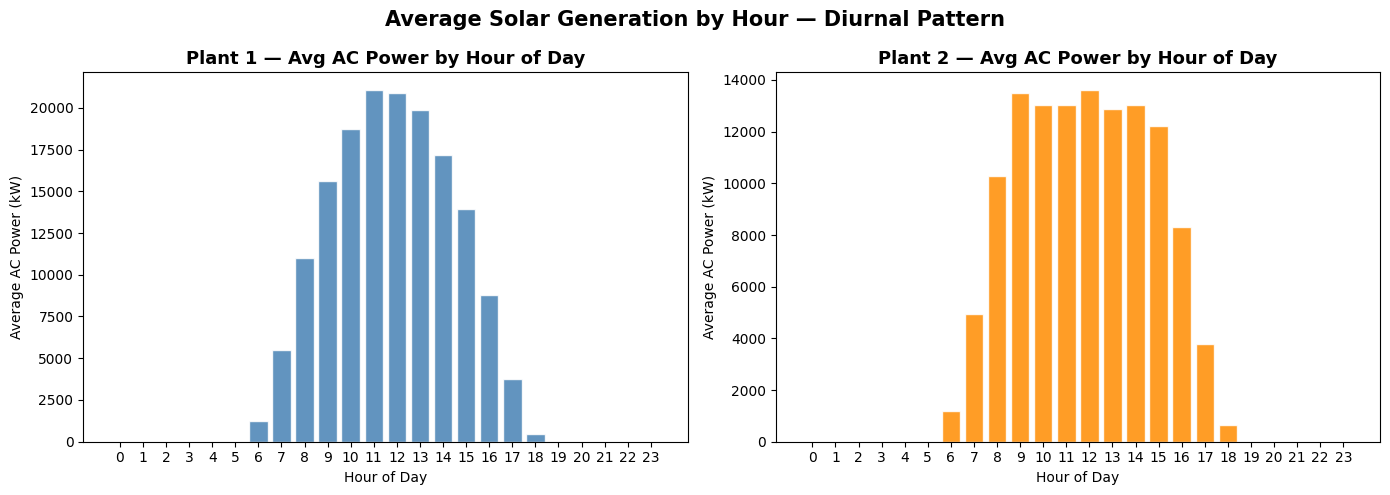

Figure 4 saved.


In [ ]:
# ============================================================
# 10. Average AC Power by Hour of Day
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p1_hourly = p1.groupby('HOUR')['AC_POWER'].mean()
p2_hourly = p2.groupby('HOUR')['AC_POWER'].mean()

axes[0].bar(p1_hourly.index, p1_hourly.values,
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Plant 1 — Avg AC Power by Hour of Day',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average AC Power (kW)')
axes[0].set_xticks(range(0, 24))

axes[1].bar(p2_hourly.index, p2_hourly.values,
            color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Plant 2 — Avg AC Power by Hour of Day',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average AC Power (kW)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Average Solar Generation by Hour — Diurnal Pattern',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

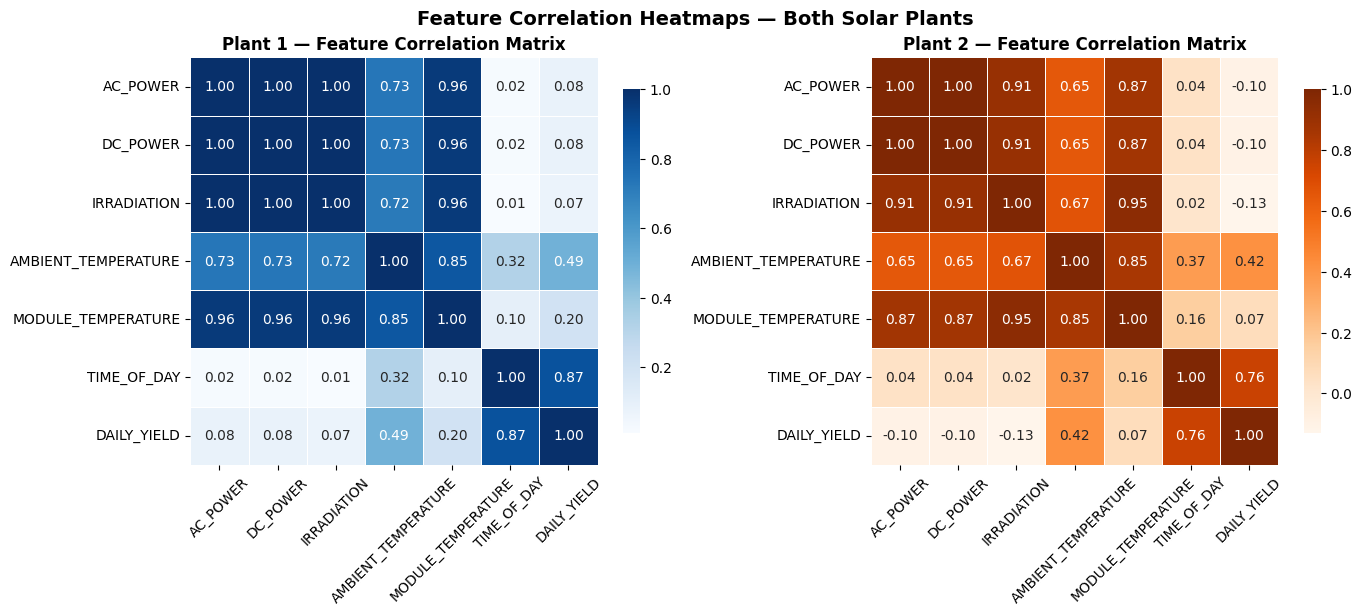

Figure 5 saved.


In [ ]:
# ============================================================
# 11. Correlation Heatmap
# ============================================================
features_for_corr = ['AC_POWER', 'DC_POWER', 'IRRADIATION',
                     'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
                     'TIME_OF_DAY', 'DAILY_YIELD']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title, cmap in zip(
    axes, [p1, p2],
    ['Plant 1 — Feature Correlation Matrix',
     'Plant 2 — Feature Correlation Matrix'],
    ['Blues', 'Oranges']):

    corr = df[features_for_corr].corr().round(2)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap,
                ax=ax, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Feature Correlation Heatmaps — Both Solar Plants',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

In [ ]:
# ============================================================
# 12. Prepare Modeling Dataset (Both Plants)
# ============================================================

FEATURES = ['IRRADIATION', 'AMBIENT_TEMPERATURE',
            'MODULE_TEMPERATURE', 'TIME_OF_DAY',
            'HOUR', 'DAY_OF_WEEK', 'DAY_OF_MONTH']
TARGET = 'AC_POWER'

# Filter to daytime only (irradiation > 0)
# — nighttime zeros are trivial to predict and skew metrics
p1_day = p1[p1['IRRADIATION'] > 0].copy()
p2_day = p2[p2['IRRADIATION'] > 0].copy()

print(f"Plant 1 — daytime rows: {len(p1_day)} / {len(p1)} total")
print(f"Plant 2 — daytime rows: {len(p2_day)} / {len(p2)} total")

# Prepare X and y for each plant
X1 = p1_day[FEATURES]
y1 = p1_day[TARGET]

X2 = p2_day[FEATURES]
y2 = p2_day[TARGET]

print(f"\nFeature matrix shapes — Plant 1: {X1.shape}, Plant 2: {X2.shape}")
print(f"Any nulls — Plant 1: {X1.isnull().sum().sum()}, Plant 2: {X2.isnull().sum().sum()}")

Plant 1 — daytime rows: 1754 / 3157 total
Plant 2 — daytime rows: 1862 / 3259 total

Feature matrix shapes — Plant 1: (1754, 7), Plant 2: (1862, 7)
Any nulls — Plant 1: 0, Plant 2: 0


In [ ]:
# ============================================================
# 13. Train/Test Split (time-based, not random)
# ============================================================
# We use time-based split — last 20% of days = test set
# This mimics real forecasting: train on past, predict future
# Important: do NOT use random split for time series data

def time_split(X, y, df, test_ratio=0.2):
    split_idx = int(len(df) * (1 - test_ratio))
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]
    return X_train, X_test, y_train, y_test

X1_train, X1_test, y1_train, y1_test = time_split(X1, y1, p1_day)
X2_train, X2_test, y2_train, y2_test = time_split(X2, y2, p2_day)

print("Plant 1 — Train:", X1_train.shape, "| Test:", X1_test.shape)
print("Plant 2 — Train:", X2_train.shape, "| Test:", X2_test.shape)

Plant 1 — Train: (1403, 7) | Test: (351, 7)
Plant 2 — Train: (1489, 7) | Test: (373, 7)


In [ ]:
# ============================================================
# 14. Evaluation Helper Function
# ============================================================
def evaluate_model(name, y_test, y_pred, plant):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"  [{plant}] {name:25s} | RMSE: {rmse:8.1f} | MAE: {mae:8.1f} | R²: {r2:.4f}")
    return {'Plant': plant, 'Model': name, 'RMSE': round(rmse,1),
            'MAE': round(mae,1), 'R2': round(r2,4)}

In [ ]:
# ============================================================
# 15. Train All Three Models
# ============================================================
results = []

print("=" * 70)
print("PLANT 1 RESULTS")
print("=" * 70)

# --- Linear Regression ---
lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)
results.append(evaluate_model('Linear Regression',
               y1_test, lr1.predict(X1_test), 'Plant 1'))

# --- Random Forest ---
rf1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf1.fit(X1_train, y1_train)
results.append(evaluate_model('Random Forest',
               y1_test, rf1.predict(X1_test), 'Plant 1'))

# --- XGBoost ---
xgb1 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42,
                          verbosity=0)
xgb1.fit(X1_train, y1_train,
         eval_set=[(X1_test, y1_test)],
         verbose=False)
results.append(evaluate_model('XGBoost',
               y1_test, xgb1.predict(X1_test), 'Plant 1'))

print("\n" + "=" * 70)
print("PLANT 2 RESULTS")
print("=" * 70)

# --- Linear Regression ---
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
results.append(evaluate_model('Linear Regression',
               y2_test, lr2.predict(X2_test), 'Plant 2'))

# --- Random Forest ---
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
results.append(evaluate_model('Random Forest',
               y2_test, rf2.predict(X2_test), 'Plant 2'))

# --- XGBoost ---
xgb2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42,
                          verbosity=0)
xgb2.fit(X2_train, y2_train,
         eval_set=[(X2_test, y2_test)],
         verbose=False)
results.append(evaluate_model('XGBoost',
               y2_test, xgb2.predict(X2_test), 'Plant 2'))

# Summary table
results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(results_df.to_string(index=False))

PLANT 1 RESULTS
  [Plant 1] Linear Regression         | RMSE:   1022.4 | MAE:    788.7 | R²: 0.9821
  [Plant 1] Random Forest             | RMSE:    656.6 | MAE:    424.1 | R²: 0.9926
  [Plant 1] XGBoost                   | RMSE:    614.7 | MAE:    417.5 | R²: 0.9935

PLANT 2 RESULTS
  [Plant 2] Linear Regression         | RMSE:   3371.4 | MAE:   2595.4 | R²: 0.5824
  [Plant 2] Random Forest             | RMSE:   2556.0 | MAE:   1401.7 | R²: 0.7600
  [Plant 2] XGBoost                   | RMSE:   2481.0 | MAE:   1271.2 | R²: 0.7738

SUMMARY TABLE
  Plant             Model   RMSE    MAE     R2
Plant 1 Linear Regression 1022.4  788.7 0.9821
Plant 1     Random Forest  656.6  424.1 0.9926
Plant 1           XGBoost  614.7  417.5 0.9935
Plant 2 Linear Regression 3371.4 2595.4 0.5824
Plant 2     Random Forest 2556.0 1401.7 0.7600
Plant 2           XGBoost 2481.0 1271.2 0.7738


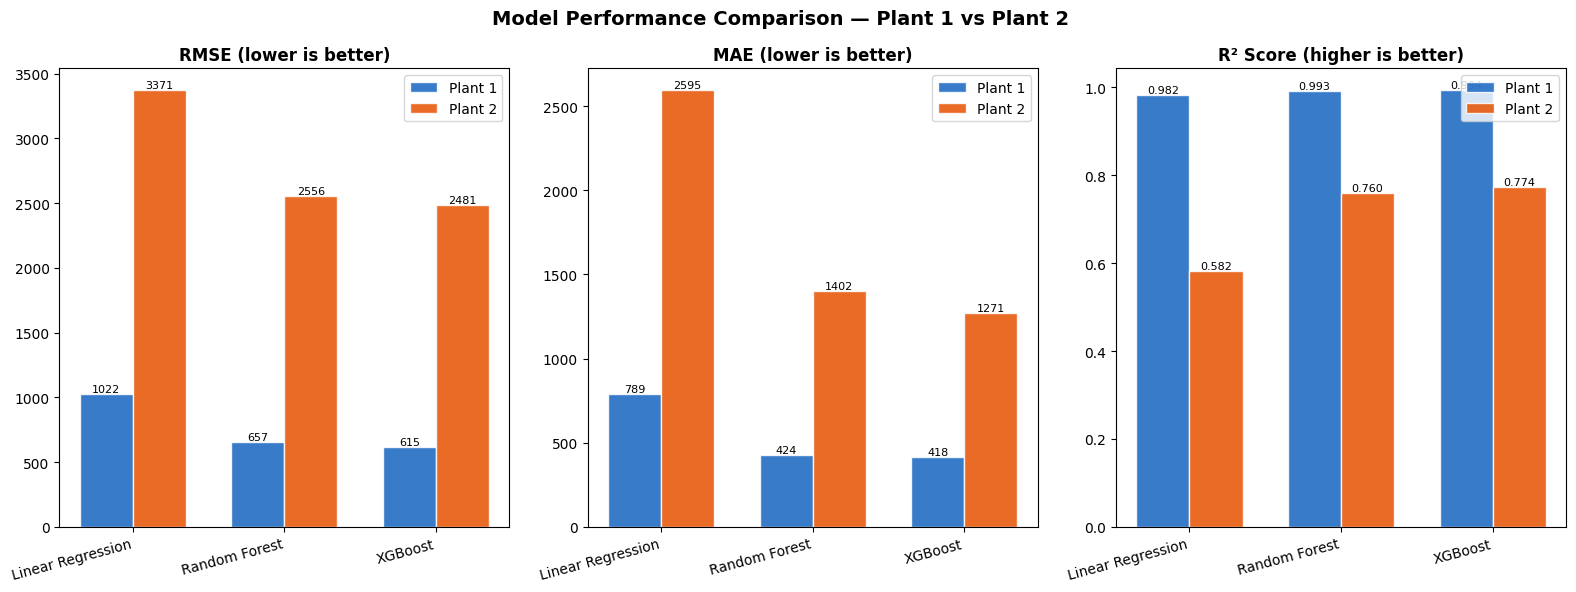

Figure 6 saved.


In [ ]:
# ============================================================
# 16. Results Comparison Chart
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

models = ['Linear Regression', 'Random Forest', 'XGBoost']
colors_p1 = ['#2196F3', '#1565C0', '#0D47A1']
colors_p2 = ['#FF9800', '#E65100', '#BF360C']

metrics = ['RMSE', 'MAE', 'R2']
titles  = ['RMSE (lower is better)',
           'MAE (lower is better)',
           'R² Score (higher is better)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    p1_vals = results_df[results_df['Plant']=='Plant 1'][metric].values
    p2_vals = results_df[results_df['Plant']=='Plant 2'][metric].values

    x = np.arange(len(models))
    width = 0.35

    bars1 = axes[i].bar(x - width/2, p1_vals, width,
                         label='Plant 1', color=colors_p1[1],
                         alpha=0.85, edgecolor='white')
    bars2 = axes[i].bar(x + width/2, p2_vals, width,
                         label='Plant 2', color=colors_p2[1],
                         alpha=0.85, edgecolor='white')

    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models, rotation=15, ha='right')
    axes[i].legend()

    # Add value labels on bars
    for bar in bars1:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h,
                    f'{h:.3f}' if metric=='R2' else f'{h:.0f}',
                    ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., h,
                    f'{h:.3f}' if metric=='R2' else f'{h:.0f}',
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison — Plant 1 vs Plant 2',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

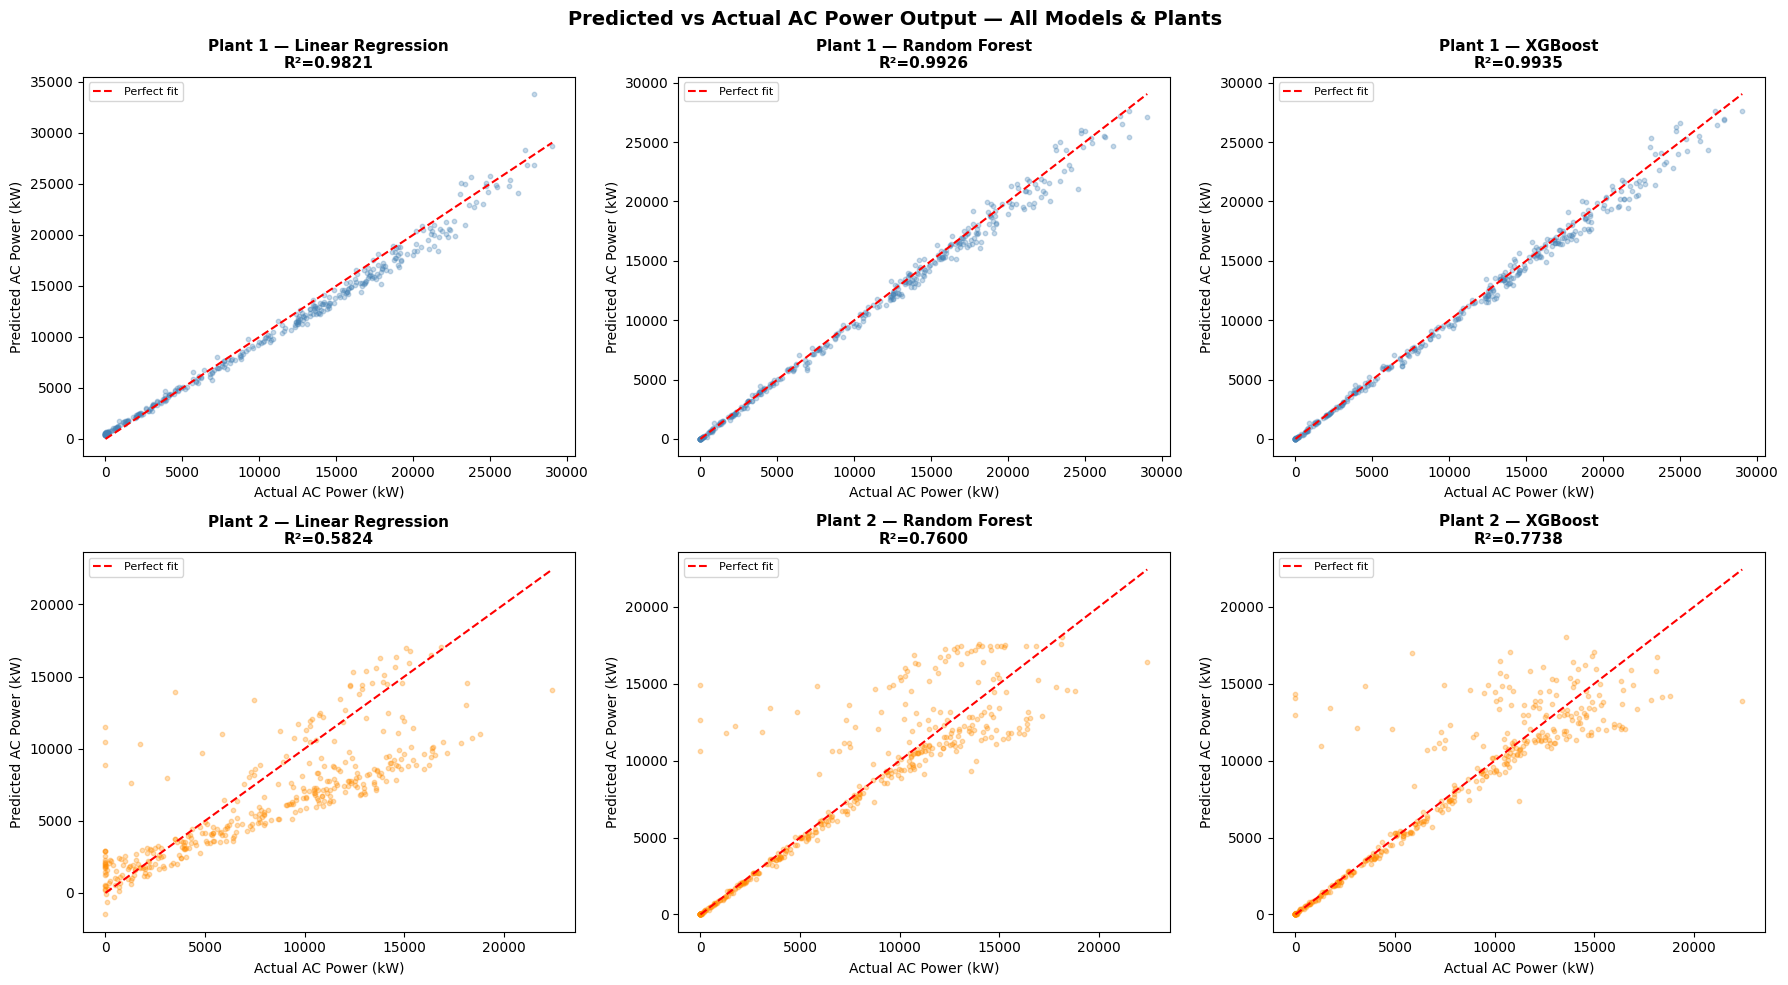

Figure 7 saved.


In [ ]:
# ============================================================
# 17. Predicted vs Actual
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = ['Linear Regression', 'Random Forest', 'XGBoost']
p1_models = [lr1, rf1, xgb1]
p2_models = [lr2, rf2, xgb2]

for j, (name, m1, m2) in enumerate(zip(model_names, p1_models, p2_models)):

    # Plant 1
    y1_pred = m1.predict(X1_test)
    axes[0][j].scatter(y1_test, y1_pred, alpha=0.3,
                       color='steelblue', s=10)
    min_v, max_v = y1_test.min(), y1_test.max()
    axes[0][j].plot([min_v, max_v], [min_v, max_v],
                    'r--', linewidth=1.5, label='Perfect fit')
    r2 = r2_score(y1_test, y1_pred)
    axes[0][j].set_title(f'Plant 1 — {name}\nR²={r2:.4f}',
                          fontsize=11, fontweight='bold')
    axes[0][j].set_xlabel('Actual AC Power (kW)')
    axes[0][j].set_ylabel('Predicted AC Power (kW)')
    axes[0][j].legend(fontsize=8)

    # Plant 2
    y2_pred = m2.predict(X2_test)
    axes[1][j].scatter(y2_test, y2_pred, alpha=0.3,
                       color='darkorange', s=10)
    min_v, max_v = y2_test.min(), y2_test.max()
    axes[1][j].plot([min_v, max_v], [min_v, max_v],
                    'r--', linewidth=1.5, label='Perfect fit')
    r2 = r2_score(y2_test, y2_pred)
    axes[1][j].set_title(f'Plant 2 — {name}\nR²={r2:.4f}',
                          fontsize=11, fontweight='bold')
    axes[1][j].set_xlabel('Actual AC Power (kW)')
    axes[1][j].set_ylabel('Predicted AC Power (kW)')
    axes[1][j].legend(fontsize=8)

plt.suptitle('Predicted vs Actual AC Power Output — All Models & Plants',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

Calculating SHAP values — this takes ~30 seconds...


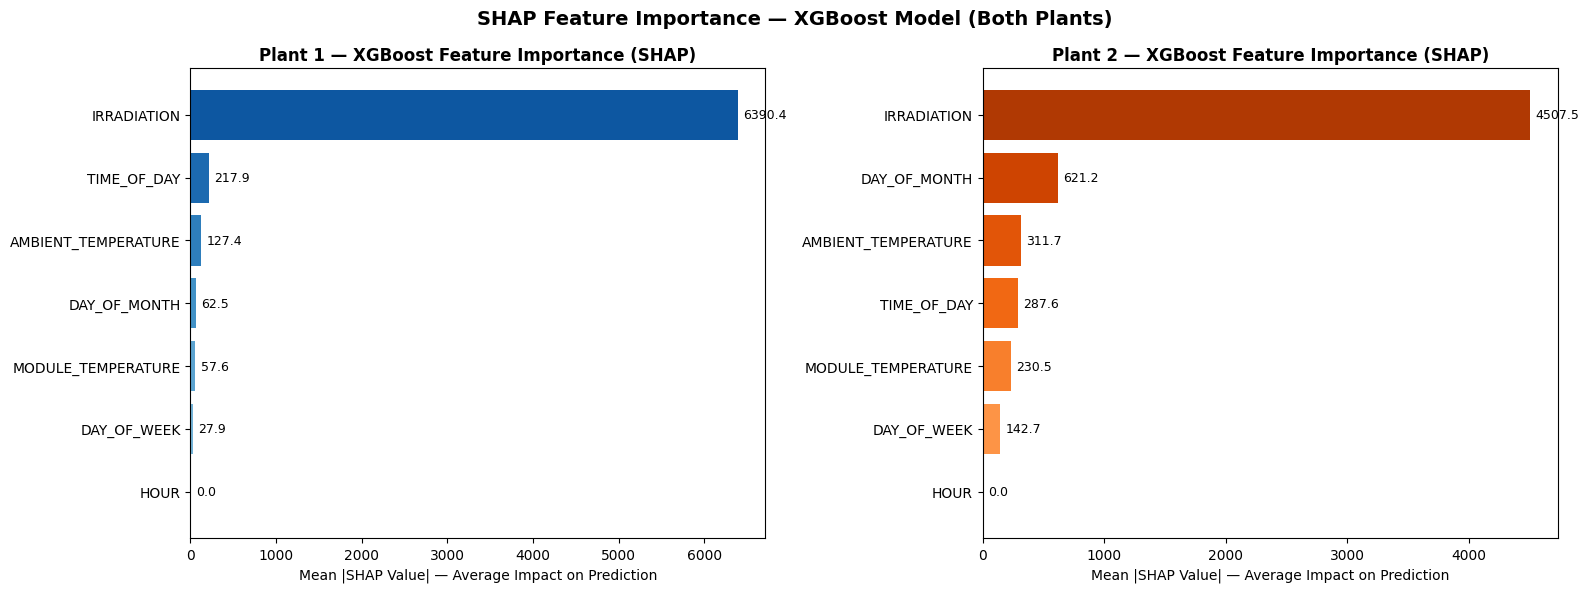

Figure 8 saved.


In [ ]:
# ============================================================
# 18. SHAP Values for XGBoost
# ============================================================
print("Calculating SHAP values — this takes ~30 seconds...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, X_test, plant, color in zip(
    axes,
    [xgb1, xgb2],
    [X1_test, X2_test],
    ['Plant 1', 'Plant 2'],
    ['Blues', 'Oranges']):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # Mean absolute SHAP per feature
    mean_shap = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=FEATURES
    ).sort_values(ascending=True)

    bars = ax.barh(mean_shap.index, mean_shap.values,
                   color=plt.cm.get_cmap(color)(
                       np.linspace(0.4, 0.85, len(mean_shap))))
    ax.set_title(f'{plant} — XGBoost Feature Importance (SHAP)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value| — Average Impact on Prediction')

    # Add value labels
    for bar, val in zip(bars, mean_shap.values):
        ax.text(val + mean_shap.max()*0.01, bar.get_y() +
                bar.get_height()/2, f'{val:.1f}',
                va='center', fontsize=9)

plt.suptitle('SHAP Feature Importance — XGBoost Model (Both Plants)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

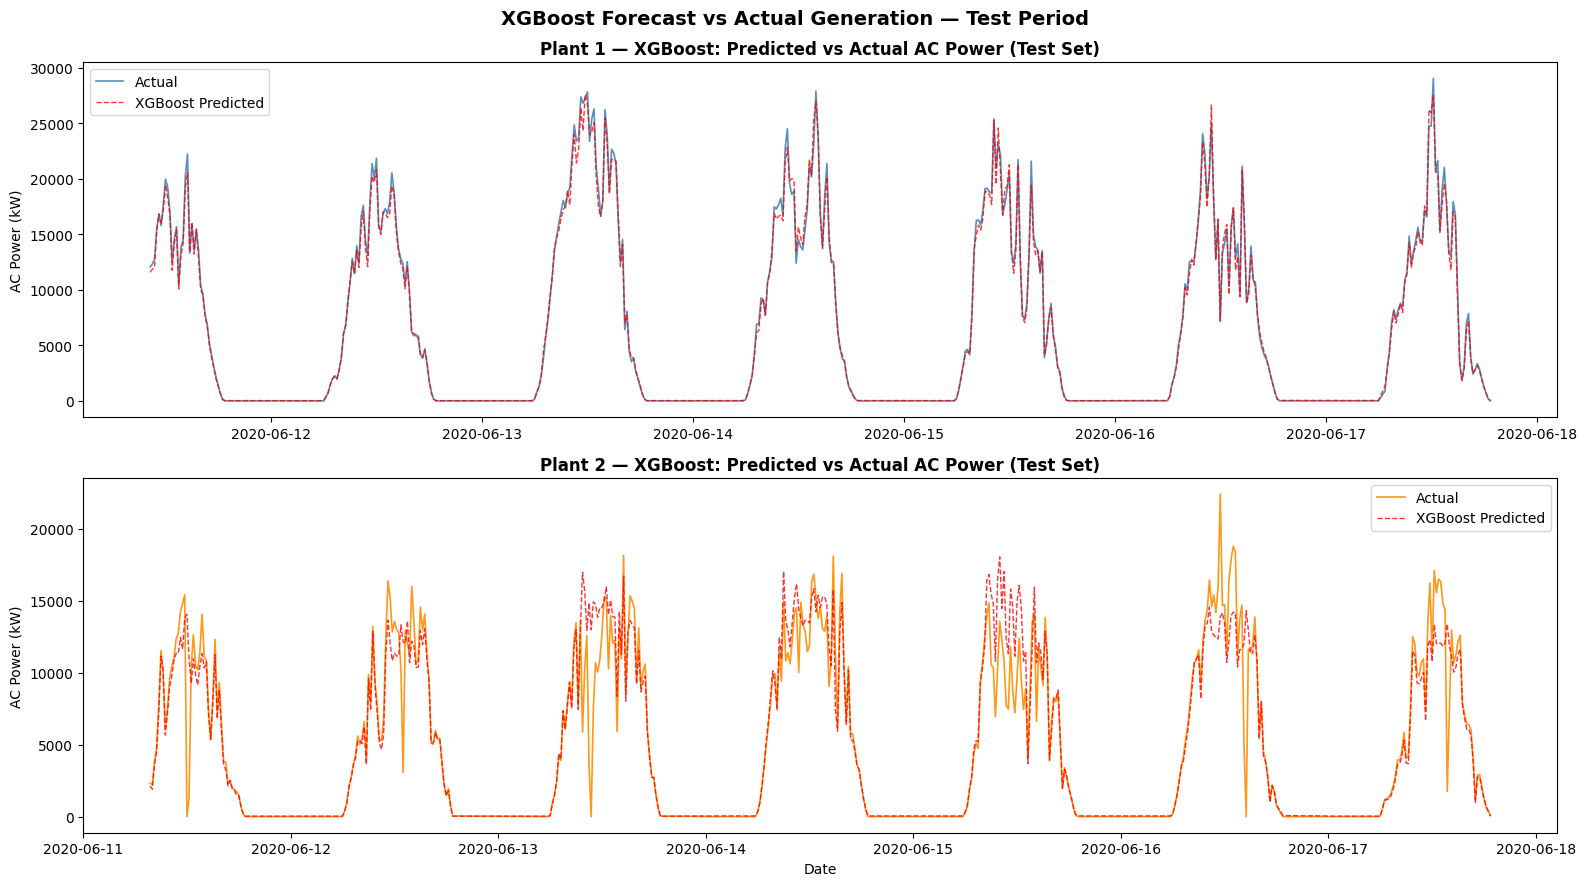

Figure 9 saved.


In [ ]:
# ============================================================
# 19. Time Series: Predicted vs Actual for XGBoost
#
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Get test set datetimes
p1_test_dates = p1_day.iloc[int(len(p1_day)*0.8):]['DATE_TIME']
p2_test_dates = p2_day.iloc[int(len(p2_day)*0.8):]['DATE_TIME']

# Plant 1
y1_pred_xgb = xgb1.predict(X1_test)
axes[0].plot(p1_test_dates.values, y1_test.values,
             color='steelblue', linewidth=1.2,
             label='Actual', alpha=0.9)
axes[0].plot(p1_test_dates.values, y1_pred_xgb,
             color='red', linewidth=1.0,
             label='XGBoost Predicted', alpha=0.8, linestyle='--')
axes[0].set_title('Plant 1 — XGBoost: Predicted vs Actual AC Power (Test Set)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('AC Power (kW)')
axes[0].legend()

# Plant 2
y2_pred_xgb = xgb2.predict(X2_test)
axes[1].plot(p2_test_dates.values, y2_test.values,
             color='darkorange', linewidth=1.2,
             label='Actual', alpha=0.9)
axes[1].plot(p2_test_dates.values, y2_pred_xgb,
             color='red', linewidth=1.0,
             label='XGBoost Predicted', alpha=0.8, linestyle='--')
axes[1].set_title('Plant 2 — XGBoost: Predicted vs Actual AC Power (Test Set)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('AC Power (kW)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.suptitle('XGBoost Forecast vs Actual Generation — Test Period',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_forecast_vs_actual_timeseries.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 9 saved.")